# Grassmannian BSF

Minimal demo: DINOv3 patch activations on the rabbit images, featurized with a
**Grassmannian BSF (orthonormal frames + block TopK)**, then the top-20 concepts shown as concept manifolds (3D PCA of their
contributions) next to PCA→RGB overlays on the images they fire on.

A *concept* is a group of `group_size` latent dims; with `group_size=3` each one
is a little 3D subspace, which is what makes the 3D manifold plots meaningful.


In [1]:
%config InlineBackend.figure_format = 'png'
import matplotlib as _mpl; _mpl.rcParams['figure.dpi'] = 55  # keep embedded figure small enough for GitHub to render
import sys, pathlib

# Locate the repo root (the folder containing `bsf/`) so this runs from anywhere.
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / 'bsf').is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import torch
import einops
import matplotlib.pyplot as plt

import bsf
from bsf import data

## 1. Load images and compute DINOv3 activations

In [2]:
# Rabbit images -> DINOv3 patch activations (fp32). Needs a GPU; ~1 min.
images = data.load_rabbit_images(ROOT / 'rabbit.npz')
acts = data.dino_activations(images)

# centre by the ImageNet per-position mean, flatten, scale so ||x|| ~ sqrt(d)
acts = acts - data.POS_MEAN
x = einops.rearrange(acts, 'n p d -> (n p) d')
x = x / np.sqrt((x ** 2).sum(1).mean()) * np.sqrt(x.shape[1])
grid = data.patch_grid(acts.shape[1])
print('activations:', x.shape, '  patch grid:', grid)

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

activations: (58800, 768)   patch grid: 14


## 2. Train the Grassmannian BSF (orthonormal frames + block TopK)

In [3]:
model = bsf.GrassmannianBSF(d=x.shape[1], n_groups=256, group_size=3, l0=8)
bsf.train(model, x, epochs=300, lr=3e-3)

epoch   1/300   loss=0.5297   R2=0.5474   L0=8.0   dead=0/256


epoch   5/300   loss=0.2244   R2=0.7372   L0=8.0   dead=0/256


epoch  10/300   loss=0.1889   R2=0.7749   L0=8.0   dead=0/256


epoch  15/300   loss=0.1786   R2=0.7858   L0=8.0   dead=0/256


epoch  20/300   loss=0.1741   R2=0.7904   L0=8.0   dead=0/256


...

epoch 285/300   loss=0.1629   R2=0.8026   L0=8.0   dead=0/256


epoch 290/300   loss=0.1630   R2=0.8030   L0=8.0   dead=0/256


epoch 295/300   loss=0.1628   R2=0.8028   L0=8.0   dead=0/256


epoch 300/300   loss=0.1628   R2=0.8024   L0=8.0   dead=0/256


GrassmannianBSF()

## 3. Extract and rank the top concepts

In [4]:
# Encode every patch -> (N, G, K) codes; atoms are the decoder blocks (G, K, d).
device = next(model.parameters()).device
z = model.encode(torch.as_tensor(x, dtype=torch.float32, device=device)).detach().cpu().numpy()
atoms = model.atoms().cpu().numpy()

# Rank concepts by total energy; keep ones that fire enough.
heat = np.linalg.norm(z, axis=-1)
fire = (heat > 1e-6).sum(0)
energy = (heat ** 2).sum(0)
top = [g for g in np.argsort(-energy) if fire[g] >= 100][:20]
print('top concepts:', top)

top concepts: [np.int64(36), np.int64(128), np.int64(154), np.int64(247), np.int64(97), np.int64(132), np.int64(217), np.int64(109), np.int64(171), np.int64(242), np.int64(0), np.int64(208), np.int64(240), np.int64(243), np.int64(102), np.int64(50), np.int64(157), np.int64(187), np.int64(162), np.int64(166)]


## 4. Concept manifolds + PCA→RGB overlays

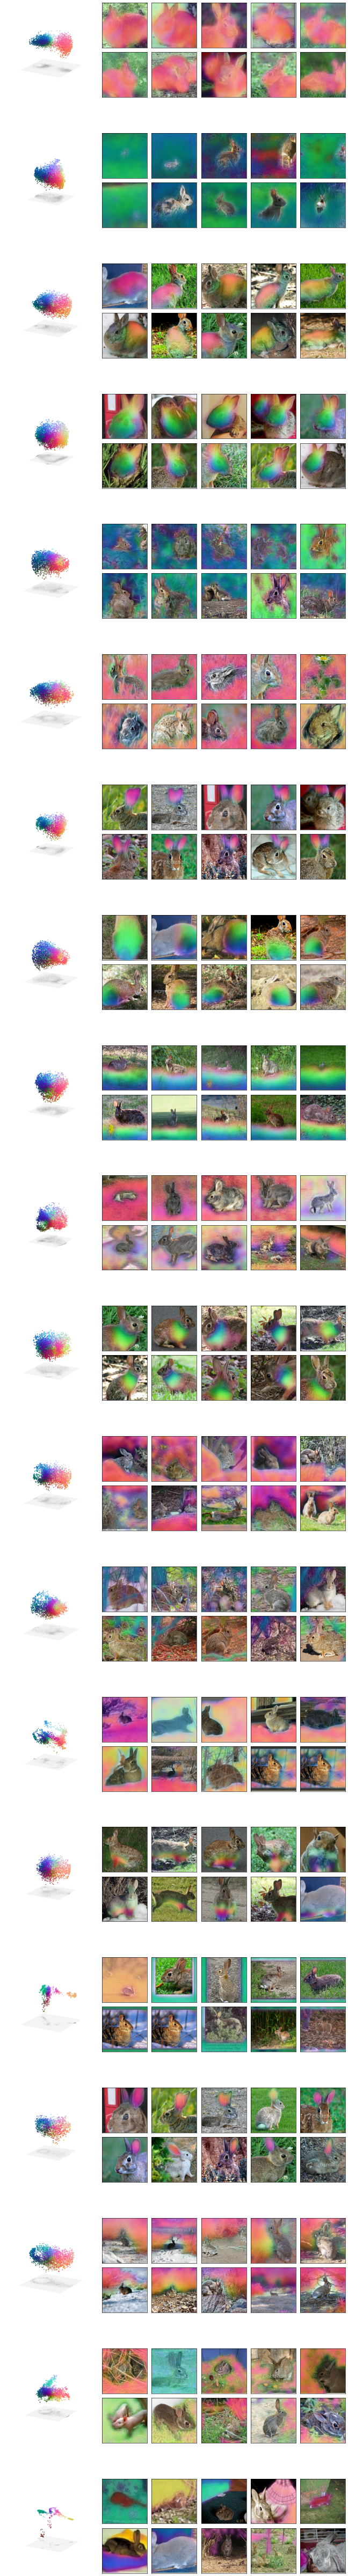

In [5]:
# One band per concept: left = 3D manifold (PCA of the contributions m_i, point
# uniform size, shadowed floor); right = a 2x5 grid of the images it fires hardest
# on, each patch tinted by its PCA->RGB coordinate (alpha = norm).
# per_axis_rgb=False normalises each PCA axis to full colour range; set False for
# one global scale centred at 0 (gray = zero, relative PC variance preserved).
bsf.viz.plot_concepts(z, atoms, images, top, grid, n_img=10, per_axis_rgb=False, point_size=4)
plt.show()